# Analysis of LLM models for RAGAS evaluations

Here I will look at the following metrics to see which models best handle use of Pubmed Central Abstracts and full text chunks to answer questions of the user. While these metrics are linked in the README.md file for this respository, what's important here is a relative comparison of the metric scores among the 4 models considered:

- granite3.3:2b
- llama3.1:8b
- qwen3:8b
- gpt-oss:20b

Most metrics were done we LLM as a Judge paradigm with OpenAI's GPT4.1. This model was the only one I found that consistently had a big enough context window to support the context load of the RAGAS metrics being evaluated.



In [12]:
# Get reports

from pathlib import Path, PosixPath
import json
from typing import Dict, List

data_dir = Path('.').parent / "reports"

def get_reports(dir: Path) -> List[PosixPath]:
    return [f for f in dir.iterdir() if f.is_file() and f.suffix == ".json"]

def load_reports(file_names: str) -> Dict:
    reports = get_reports(data_dir)
    return {f.name: json.loads(open(f).read()) for f in reports}

reports = load_reports(data_dir)
for key in reports.keys():
    print(key)

ragas_medqa_report_granite3-3-2b_search.json
ragas_medqa_report_llama3-1-8b_search.json
ragas_medqa_report_qwen3-8b_search.json
ragas_medqa_report_qwen3-8b_fulltext.json
ragas_medqa_report_llama3-1-8b_fulltext.json
ragas_medqa_report_gpt-oss-20b_search.json
ragas_medqa_report_granite3-3-2b_fulltext.json
ragas_medqa_report_gpt-oss-20b_fulltext.json


In [13]:
# Sort reports into organized metrics

import pandas as pd

search_qa_data = []
fulltext_qa_data = []

for report, data in reports.items():
    model = data.get('config').get('agent_model')
    mode = data.get('config').get('eval_mode')
    metrics = data.get('config').get('metrics')
    summary = {f"{metric}_mean": data.get('summary').get(f'{metric}_mean') for metric in metrics}
    summary.update({"model": model})
    if mode == "search":
        search_qa_data.append(summary)
    elif mode == 'fulltext':
        fulltext_qa_data.append(summary)
    else:
        continue

search_qa = pd.DataFrame(search_qa_data)
fulltext_qa = pd.DataFrame(fulltext_qa_data)

In [18]:
print("search qa metrics\n")
search_qa.set_index('model').head()


search qa metrics



,noise_sensitivity_mean,answer_relevancy_mean,answer_similarity_mean,answer_accuracy_mean,context_precision_mean
model,,,,,
granite3.3:2b,0.072115,0.906399,0.694677,0.250000,0.277778
llama3.1:8b,0.169516,0.634501,0.498310,0.166667,0.277778
qwen3:8b,0.138889,0.821832,0.614390,0.333333,0.277778
gpt-oss:20b,0.125356,0.803897,0.569464,0.250000,0.444444


In [19]:
print("fulltext qa metrics\n")
fulltext_qa.set_index('model').head()

fulltext qa metrics



,answer_relevancy_mean
model,
qwen3:8b,0.813065
llama3.1:8b,0.558749
granite3.3:2b,0.786820
gpt-oss:20b,0.726883


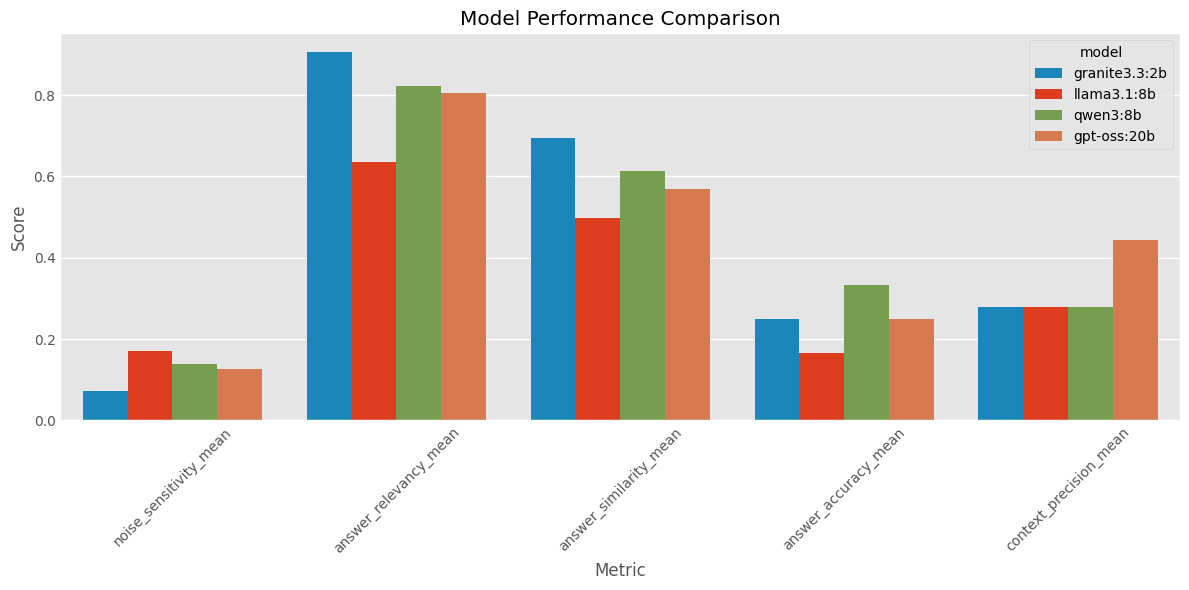

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# style customizations
plt.style.use('ggplot') 

model_colors = {
    'granite3.3:2b': '#008FD5',
    'llama3.1:8b': '#FF2700',   
    'qwen3:8b': '#77AB43',      
    'gpt-oss:20b': '#ed713a'    
}

df_search = search_qa.melt(id_vars='model', var_name='Metric', value_name='Score')


plt.figure(figsize=(12, 6))
sns.barplot(data=df_search, x='Metric', y='Score', hue='model', palette=model_colors)

plt.title('Model Performance Comparison')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

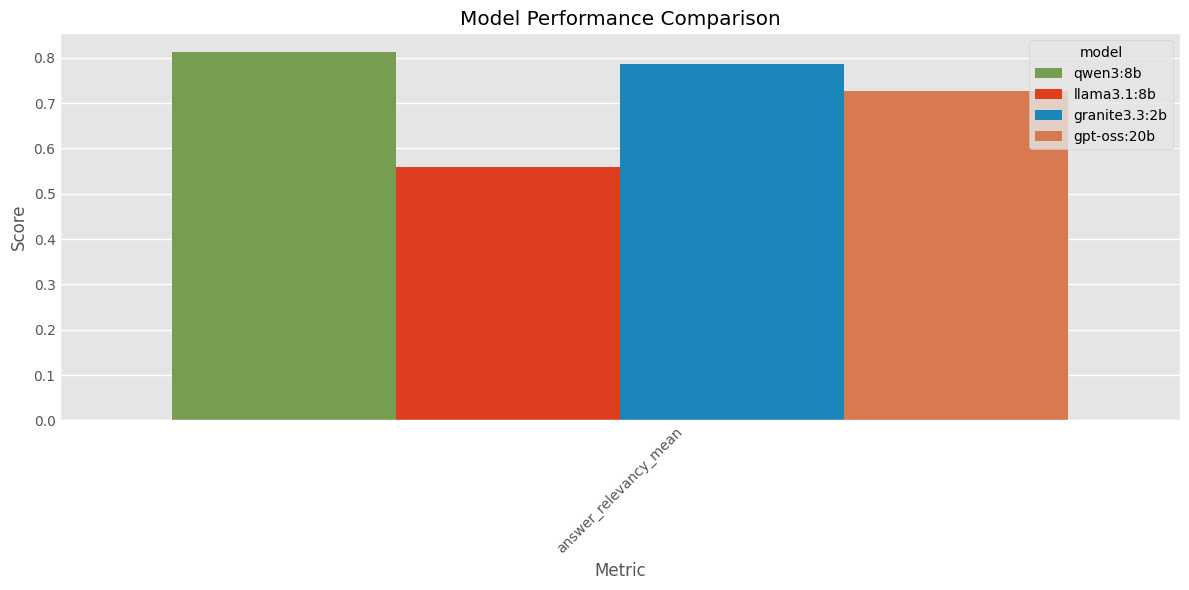

In [21]:
df_fulltext = fulltext_qa.melt(id_vars='model', var_name='Metric', value_name='Score')


plt.figure(figsize=(12, 6))
sns.barplot(data=df_fulltext, x='Metric', y='Score', hue='model', palette=model_colors)

plt.title('Model Performance Comparison')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Discussion

The results show that granite and qwen trade often trade top positions in the scoring metrics in using the contexts provided by either the search results of the PMC abstracts or the document sections for document-specific question and answering. What is clear is that the model initially used for building and testing the application functionality, gpt-oss:20b, is not the top performer. 

These results are less meaningful in and of themselves, but do show that comparatively, some models make more accurate use of the retrieved information for crafting a response. The metrics specific for the search response take into accound the MedQA reference answer as a source of comparison. While the wordiness of the chat response in comparison to the compact MedQA answer do not align that well, the comparative performance is telling. It shows in reference to the task of making use of the PubMed abstracts, qwen and granite perform the best.

These results suggest another round of readability evaluation is in order to see how well they do in presenting a medical response in non-technical language while preventing information loss. The first round was conducted with gpt-oss:20b, but the second round will determinte whether Qwen or Granite is selected as the top performing model for the medlit_agent LLM.